**Shruti Gupta (12301032025) IT2 branch**

Exploratory Data Analysis (EDA) and  
Machine Learning on Agricultural Yield Dataset

In [2]:
#importing libraries and reading dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/agriculture_yield_dataset.csv")



Part A: Understanding the Dataset
Q1. Dataset Overview
Load the dataset and answer the following:
 How many rows and columns are present?  
 What are the names of all columns?  
 Display the first 10 records.

In [3]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

Q2. Data Types and Missing Values
 Check the data type of each column.  
 Identify whether any missing values are present.  
 If missing values exist, mention the affected columns.

In [4]:
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
missing_cols = df.columns[df.isnull().sum() > 0]
print("\nColumns with Missing Values:")
print(missing_cols)


Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
Index([], dtype='object')


Q3. Descriptive Statistics
Generate summary statistics for all numerical features and answer:
 Which feature has the highest mean value?  
 Which feature has the highest standard deviation?

In [5]:
print("\nSummary Statistics:")
print(df.describe())
numeric_cols=df.select_dtypes(include=np.number)
print("\nFeature with Highest Mean:")
print(numeric_cols.mean().idxmax())
print("\nFeature with Highest Standard Deviation:")
print(numeric_cols.std().idxmax())


Summary Statistics:
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.74000

Part B: Exploratory Data Analysis (EDA)


Q4. Distribution Analysis
Create histograms for:
 rainfall_mm  
 temperature_c  
 fertilizer_kg  
 yield_ton_per_hectare  
Write 2–3 observations from each histogram.

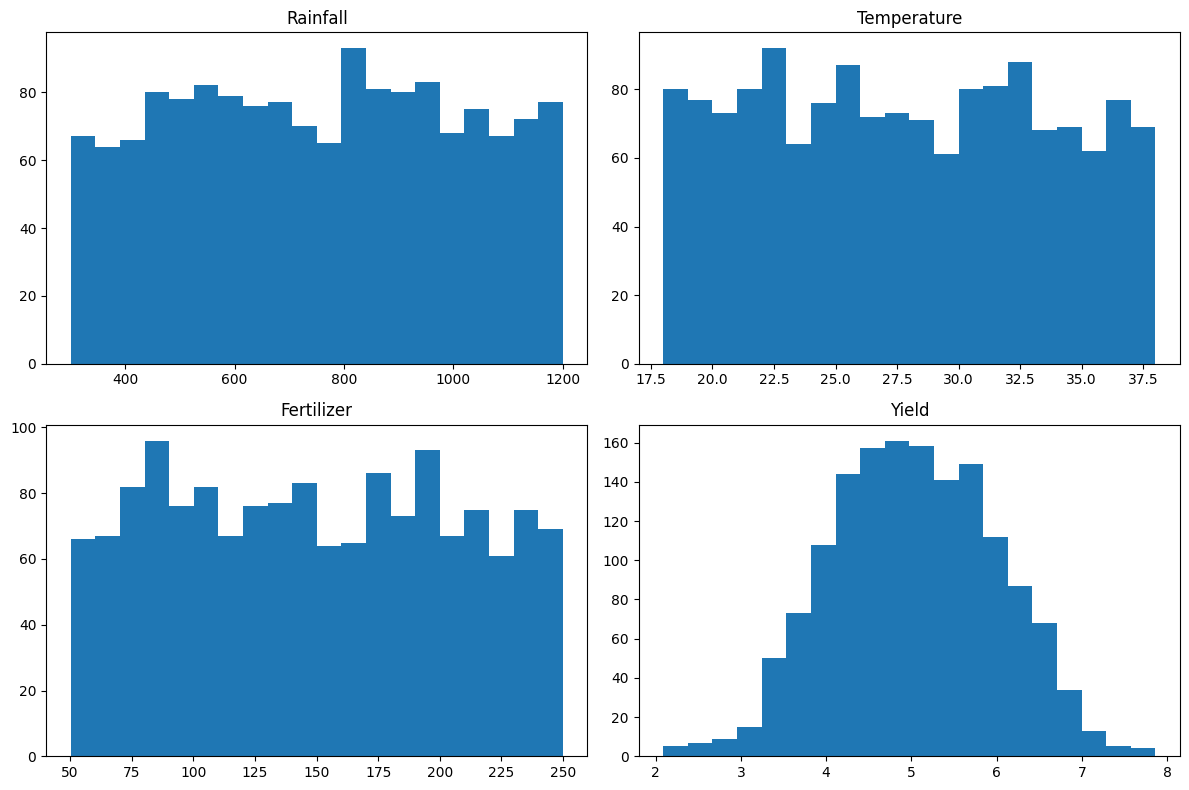

In [27]:
fig,ax=plt.subplots(2,2,figsize=(12, 8))

ax[0,0].hist(df["rainfall_mm"],bins=20)
ax[0,0].set_title("Rainfall")

ax[0,1].hist(df["temperature_c"],bins=20)
ax[0,1].set_title("Temperature")

ax[1,0].hist(df["fertilizer_kg"],bins=20)
ax[1,0].set_title("Fertilizer")

ax[1,1].hist(df["yield_ton_per_hectare"],bins=20)
ax[1,1].set_title("Yield")

plt.tight_layout()
plt.show()

Rainfall (rainfall_mm)

Rainfall values are fairly evenly distributed across the range.

No strong skewness is observed in the distribution.

There are no obvious outliers.

Temperature (temperature_c)

Temperature values are spread relatively uniformly between about 18°C and 38°C.

Most temperature ranges have similar frequencies.

No significant outliers are visible.

Fertilizer (fertilizer_kg)
Fertilizer usage is distributed fairly evenly across the dataset.

There is moderate variation in fertilizer application levels.

No major concentration or extreme outliers are observed.

Yield
(yield_ton_per_hectare)

The distribution is approximately bell-shaped (normal).

Most yield values are concentrated around 4–6 tons per hectare.

Very few observations occur at the extreme low and high ends, indicating no major outliers.

Q5. Crop Type Analysis
 Find the number of records for each crop type.  
 Create a count plot (bar chart) for crop_type.  
 Which crop appears most frequently?


Crop Type Counts:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


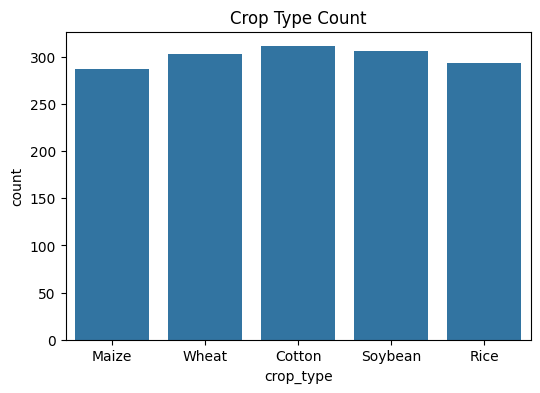


Most Frequent Crop:
Cotton


In [7]:
print("\nCrop Type Counts:")
print(df["crop_type"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x="crop_type", data=df)
plt.title("Crop Type Count")
plt.show()

print("\nMost Frequent Crop:")
print(df["crop_type"].value_counts().idxmax())

Q6. Soil Type Analysis
 Find the frequency of each soil type.  
 Create a count plot for soil_type.  
 Which soil type is most common?


Soil Type Counts:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


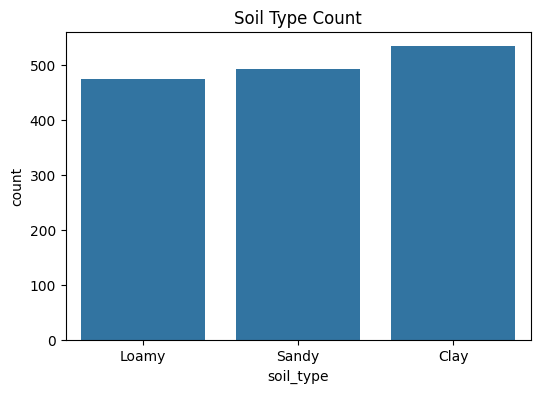


Most Common Soil Type:
Clay


In [8]:
print("\nSoil Type Counts:")
print(df["soil_type"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x="soil_type", data=df)
plt.title("Soil Type Count")
plt.show()

print("\nMost Common Soil Type:")
print(df["soil_type"].value_counts().idxmax())

Q7. Yield Distribution
Create a histogram of yield_ton_per_hectare.
Answer:
 Is the distribution approximately normal?  
 Are there any noticeable outliers?

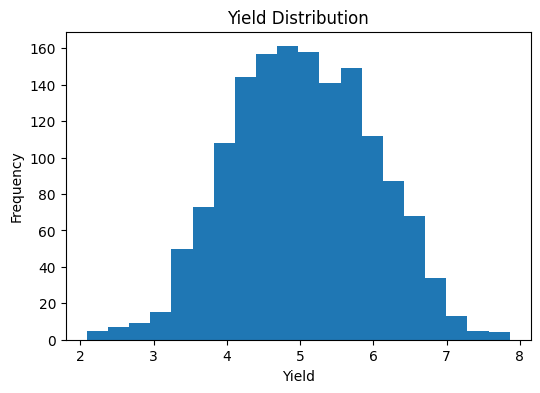

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

**Is the distribution approximately normal?**
Yes, the yield distribution is approximately normal (bell-shaped), with most values concentrated around 5 tons per hectare.

**Are there any noticeable outliers?**
No significant outliers are visible. Only a few observations occur at the extreme lower and higher yield values.

Q8. Scatter Plot Analysis
Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare  
2. fertilizer_kg vs yield_ton_per_hectare  
Based on the plots:
 Which feature appears to have a stronger relationship with yield?

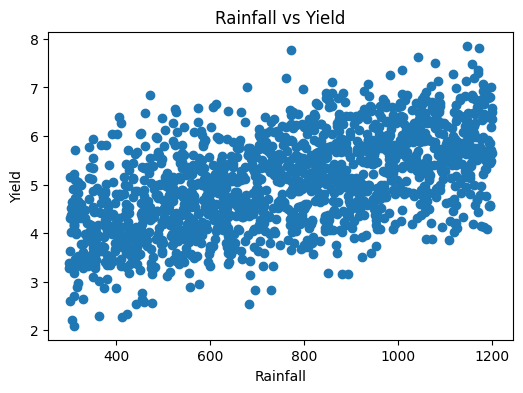

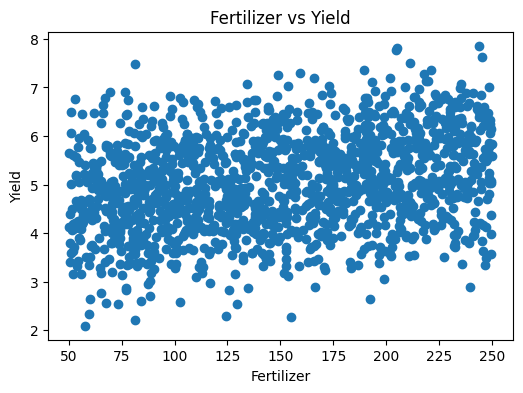

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

rainfall feature has stronger relationship with yield.

Q9. Correlation Analysis
 Generate a correlation matrix for numerical features.  
 Create a heatmap.  
 Identify the top three features most correlated with crop yield.


Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

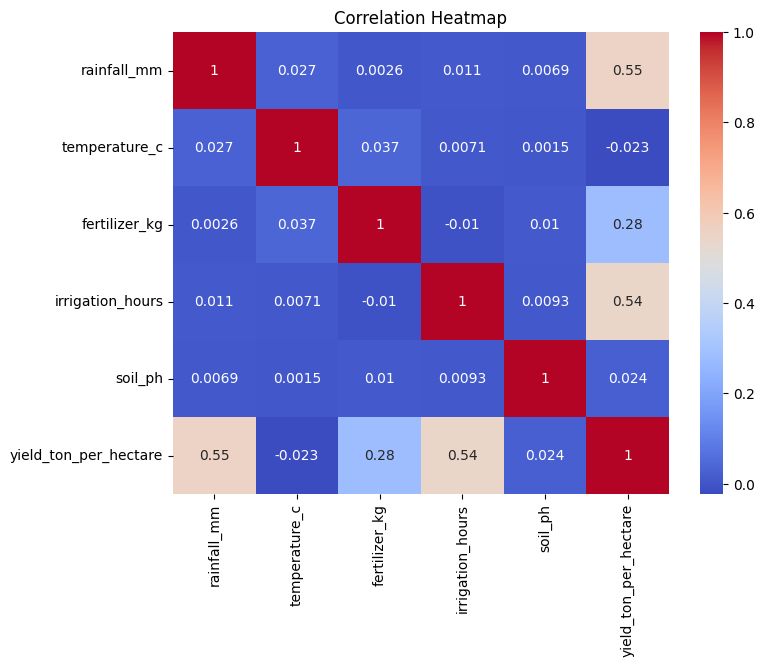


Top 3 Features Correlated with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
Name: yield_ton_per_hectare, dtype: float64


In [26]:
corr=numeric_cols.corr()
print("\nCorrelation Matrix:")
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

yield_corr=corr["yield_ton_per_hectare"].sort_values(ascending=False)
top3 = yield_corr.sort_values(ascending=False).head(3)
print("\nTop 3 Features Correlated with Yield:")
print(top3)

Q10. Group-Based Analysis
Calculate the average yield for:
 Each crop type  
 Each soil type  
Which crop and soil type have the highest average yield?

In [23]:
crop_avg=df.groupby("crop_type")["yield_ton_per_hectare"].mean()
soil_avg=df.groupby("soil_type")["yield_ton_per_hectare"].mean()

print("\nAverage Yield by Crop:")
print(crop_avg)
print("\nAverage Yield by Soil:")
print(soil_avg)
print("\nHighest Yield Crop:")
print(crop_avg.idxmax())
print("\nHighest Yield Soil:")
print(soil_avg.idxmax())


Average Yield by Crop:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


Part C: Data Preparation


Q11. Feature Encoding
The dataset contains categorical variables.
 Identify the categorical columns.  
 Convert them into numerical form using One-Hot Encoding.  
 Display the first five rows of the transformed dataset.

In [22]:
categorical_cols=df.select_dtypes(include="object").columns
print("\nCategorical Columns:")
print(categorical_cols)

df_encoded=pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nFirst Five Rows After Encoding:")
print(df_encoded.head())


Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')

First Five Rows After Encoding:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False   

Q12. Feature Selection
Separate:
 Input features (X)  
 Target variable (y)  
Specify which column is being used as the target variable.

In [21]:
X=df_encoded.drop("yield_ton_per_hectare", axis=1)
y=df_encoded["yield_ton_per_hectare"]
print("\nTarget Variable:")
print("yield_ton_per_hectare")


Target Variable:
yield_ton_per_hectare


Part D: Machine Learning


Q13. Train-Test Split
Split the dataset into:
 80% Training Data  
 20% Testing Data  
Display the shape of:
 X_train  
 X_test  
 y_train  
 y_test

> Add blockquote



In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42
)

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)


X_train Shape: (1200, 11)
X_test Shape: (300, 11)
y_train Shape: (1200,)
y_test Shape: (300,)


Q14. Linear Regression Model
 Train a Linear Regression model.  
 Display the model coefficients and intercept.  
 Which feature has the highest positive coefficient?

In [19]:
model=LinearRegression()
model.fit(X_train,y_train)

print("\nIntercept:")
print(model.intercept_)

coef_df=pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nCoefficients:")
print(coef_df)

highest_feature=coef_df.loc[
    coef_df["Coefficient"].idxmax(),
    "Feature"
]
print("\nFeature with Highest Positive Coefficient:")
print(highest_feature)


Intercept:
1.587132027736121

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Feature with Highest Positive Coefficient:
crop_type_Rice
